In [7]:
from igng import IGNG
import numpy as np
import matplotlib.pyplot as plt
import torch

In [8]:
from sklearn.datasets import (
    make_moons,
    make_circles,
    make_blobs,
    make_swiss_roll,
    make_s_curve
)

def generate_benchmarks(n_samples=5000):

    benchmarks = {}

    # =====================================================
    # 1. TWO MOONS
    # =====================================================

    X, y = make_moons(
        n_samples=n_samples,
        noise=0.05,
        random_state=42
    )

    benchmarks["moons"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 2. CIRCLES
    # =====================================================

    X, y = make_circles(
        n_samples=n_samples,
        factor=0.5,
        noise=0.03,
        random_state=42
    )

    benchmarks["circles"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 3. BLOBS
    # =====================================================

    X, y = make_blobs(
        n_samples=n_samples,
        centers=5,
        cluster_std=0.5,
        random_state=42
    )

    benchmarks["blobs"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 4. SWISS ROLL
    # =====================================================

    X, y = make_swiss_roll(
        n_samples=n_samples,
        noise=0.05,
        random_state=42
    )

    benchmarks["swiss_roll"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 5. S CURVE
    # =====================================================

    X, y = make_s_curve(
        n_samples=n_samples,
        noise=0.05,
        random_state=42
    )

    benchmarks["s_curve"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 6. LINE
    # =====================================================

    x = torch.linspace(-5, 5, n_samples)

    X = torch.stack([
        x,
        torch.zeros_like(x)
    ], dim=1)

    benchmarks["line"] = (
        X.float(),
        torch.zeros(n_samples)
    )

    # =====================================================
    # 7. CROSS
    # =====================================================

    n = n_samples // 2

    x1 = torch.rand(n) * 10 - 5
    y1 = torch.zeros(n)

    x2 = torch.zeros(n)
    y2 = torch.rand(n) * 10 - 5

    X = torch.cat([
        torch.stack([x1, y1], dim=1),
        torch.stack([x2, y2], dim=1)
    ])

    benchmarks["cross"] = (
        X.float(),
        torch.zeros(len(X))
    )

    # =====================================================
    # 8. SPIRAL
    # =====================================================

    t = torch.linspace(
        0,
        4 * np.pi,
        n_samples
    )

    x = t * torch.cos(t)
    y = t * torch.sin(t)

    X = torch.stack([x, y], dim=1)

    benchmarks["spiral"] = (
        X.float(),
        torch.zeros(len(X))
    )

    # =====================================================
    # 9. TWO SPIRALS
    # =====================================================

    n = n_samples // 2

    t = np.linspace(
        0,
        4 * np.pi,
        n
    )

    x1 = t * np.cos(t)
    y1 = t * np.sin(t)

    x2 = -t * np.cos(t)
    y2 = -t * np.sin(t)

    X = np.vstack([
        np.c_[x1, y1],
        np.c_[x2, y2]
    ])

    y = np.hstack([
        np.zeros(n),
        np.ones(n)
    ])

    benchmarks["two_spirals"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    # =====================================================
    # 10. RING + BLOB
    # =====================================================

    circle, _ = make_circles(
        n_samples=int(n_samples * 0.6),
        factor=0.7,
        noise=0.03,
        random_state=42
    )

    blob, _ = make_blobs(
        n_samples=int(n_samples * 0.4),
        centers=[[3, 3]],
        cluster_std=0.3,
        random_state=42
    )

    X = np.vstack([
        circle,
        blob
    ])

    y = np.hstack([
        np.zeros(len(circle)),
        np.ones(len(blob))
    ])

    benchmarks["ring_blob"] = (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y)
    )

    return benchmarks


# =====================================================
# EXAMPLE
# =====================================================

benchmarks = generate_benchmarks(5000)

for name, (X, y) in benchmarks.items():

    print(
        f"{name:<15} "
        f"shape={tuple(X.shape)} "
        f"classes={len(torch.unique(y))}"
    )

moons           shape=(5000, 2) classes=2
circles         shape=(5000, 2) classes=2
blobs           shape=(5000, 2) classes=5
swiss_roll      shape=(5000, 3) classes=5000
s_curve         shape=(5000, 3) classes=5000
line            shape=(5000, 2) classes=1
cross           shape=(5000, 2) classes=1
spiral          shape=(5000, 2) classes=1
two_spirals     shape=(5000, 2) classes=2
ring_blob       shape=(5000, 2) classes=2


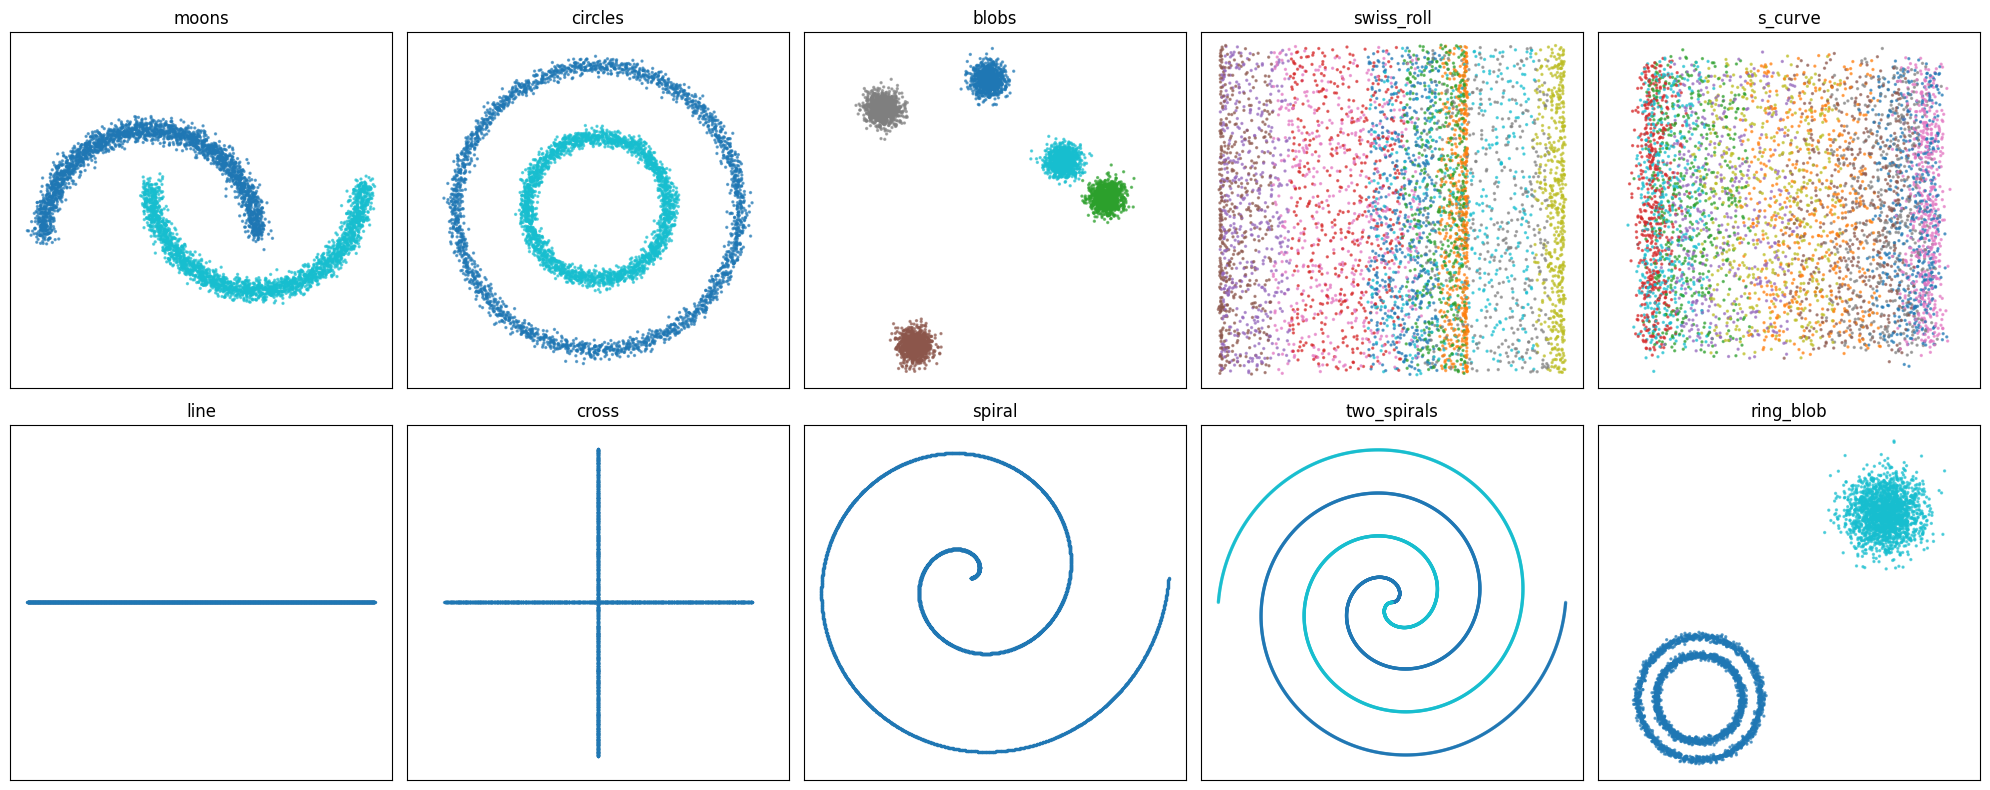

In [9]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8)
)

axes = axes.flatten()

for ax, (name, (X, y)) in zip(axes, benchmarks.items()):

    X_np = X.numpy()

    # données
    if len(torch.unique(y)) > 1:
        ax.scatter(
            X_np[:, 0],
            X_np[:, 1],
            c=y,
            s=2,
            alpha=0.6,
            cmap="tab10"
        )
    else:
        ax.scatter(
            X_np[:, 0],
            X_np[:, 1],
            s=2,
            alpha=0.6
        )

    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("equal")

plt.tight_layout()
plt.show()

IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu


C:\Users\Client\AppData\Local\Temp\ipykernel_68424\550156913.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu


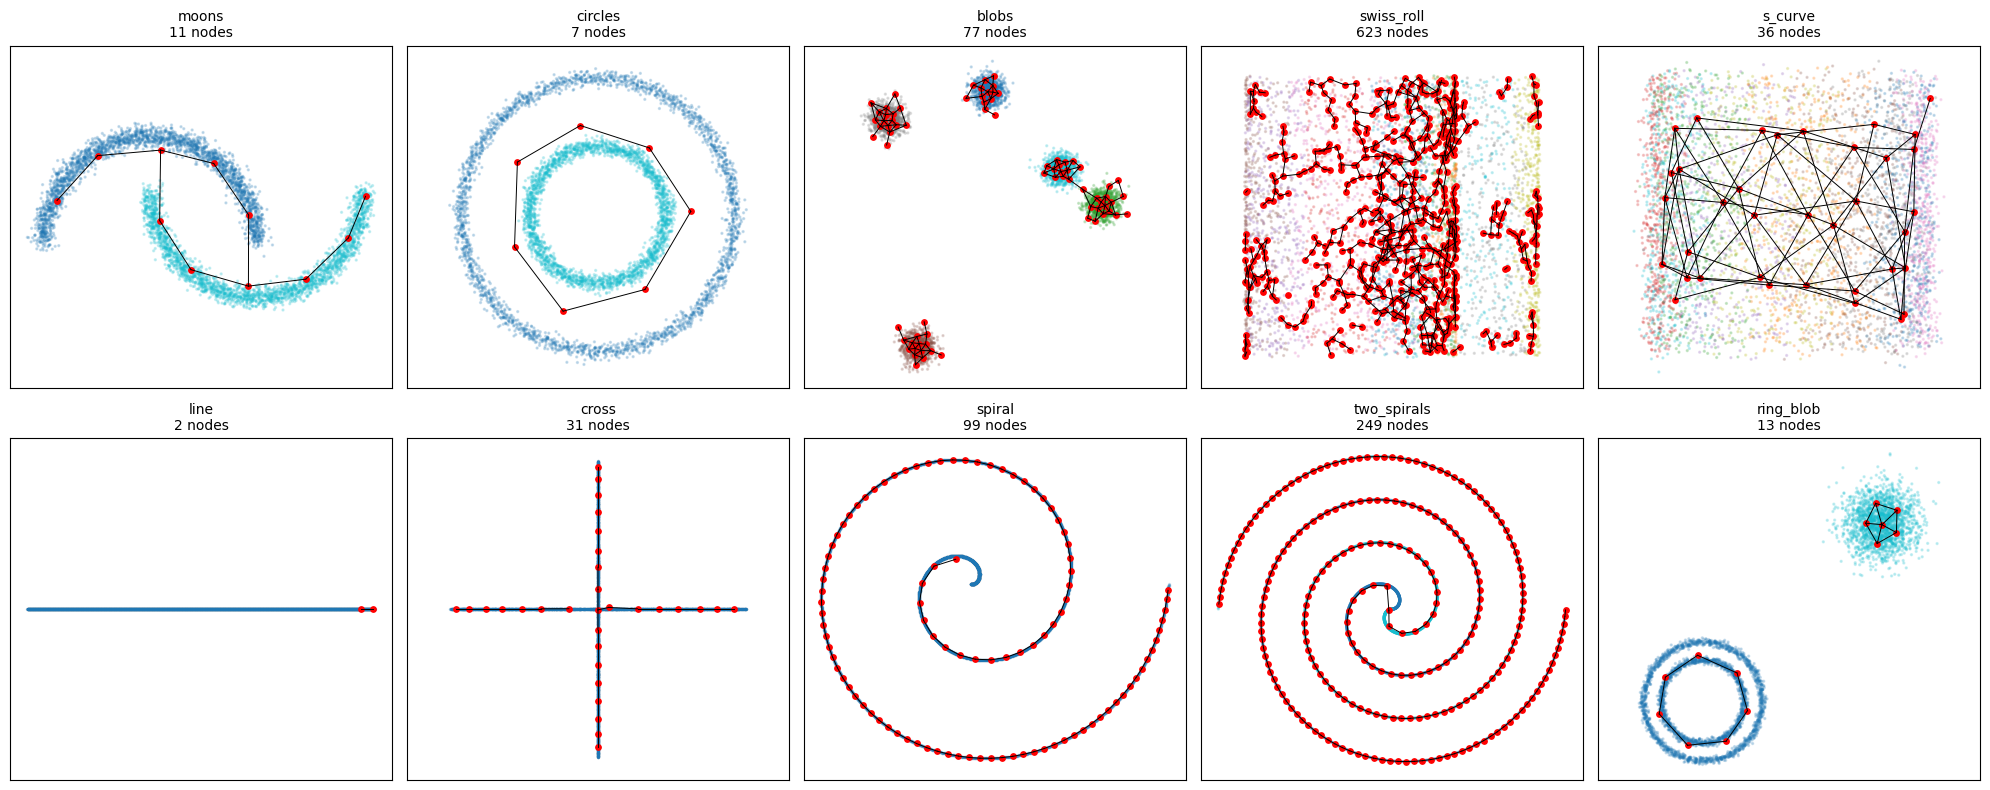

In [10]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8)
)

axes = axes.ravel()

for ax, (name, (X, y)) in zip(axes, benchmarks.items()):

    model = IGNG(
        input_dim=X.shape[1],
        sigma=1.0,
        age_max=50
    )

    model.partial_fit(X)

    X_np = X.cpu().numpy()

    # données
    ax.scatter(
        X_np[:,0],
        X_np[:,1],
        c=y.numpy() if len(torch.unique(y)) > 1 else None,
        s=2,
        alpha=0.2,
        cmap="tab10"
    )

    # arêtes
    for i, neighbors in model.edges.items():

        for j in neighbors.keys():

            if i < j:

                p1 = model.nodes[i].cpu().numpy()
                p2 = model.nodes[j].cpu().numpy()

                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    lw=0.7,
                    color="black"
                )

    # nœuds
    nodes = model.nodes.cpu().numpy()

    ax.scatter(
        nodes[:,0],
        nodes[:,1],
        s=15,
        color="red"
    )

    ax.set_title(
        f"{name}\n{len(nodes)} nodes",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("equal")

plt.tight_layout()
plt.show()

IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu
IGNG initialized on cpu


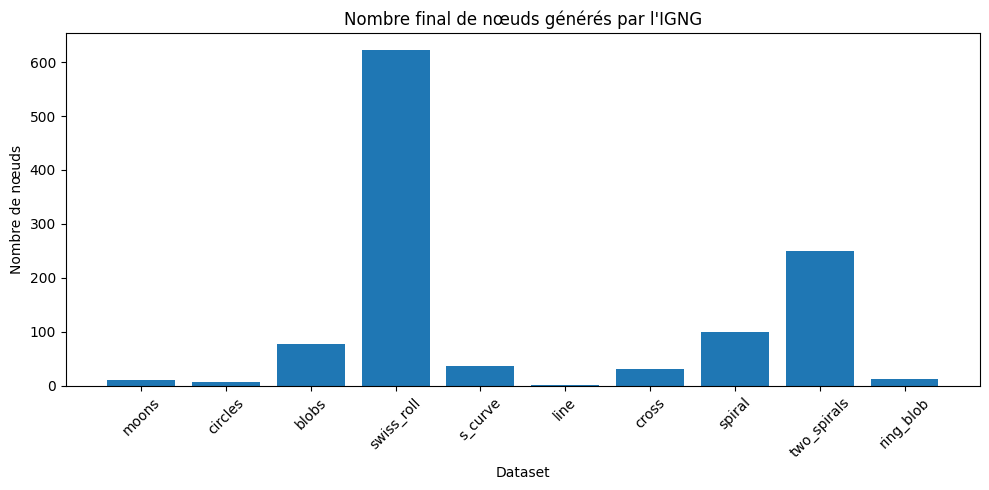

In [11]:
names = []
n_nodes = []

for name, (X, y) in benchmarks.items():

    model = IGNG(
        input_dim=X.shape[1],
        sigma=1.0,
        age_max=50
    )

    model.partial_fit(X)

    names.append(name)
    n_nodes.append(len(model.nodes))

plt.figure(figsize=(10,5))

plt.bar(names, n_nodes)

plt.ylabel("Nombre de nœuds")
plt.xlabel("Dataset")
plt.title("Nombre final de nœuds générés par l'IGNG")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()